In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import os
from PIL import Image
from torch.utils.data import Dataset

class FlatDirectoryDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # List all files and filter for images
        self.filenames = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.filenames[idx])
        # Open as RGB to ensure 3 channels (handles grayscale or RGBA PNGs)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image

In [3]:
data_path = '/home/hice1/mmagdiyev3/scratch/dl-project/data' # change this to the path where you want your dataset to be stored
images_path = data_path + 'images/images_normalized' 
!ls
if not os.listdir(data_path):
    print("Data path directory is empty, downloading the dataset from kaggle...")
    !curl -L -o ~/scratch/dl-project/data/chest-xrays-indiana-university.zip\
        https://www.kaggle.com/api/v1/datasets/download/raddar/chest-xrays-indiana-university

    !cd ~/scratch/dl-project/data/ && unzip chest-xrays-indiana-university.zip && rm chest-xrays-indiana-university.zip

batch_size = 32

data_processing.ipynb
Data path directory is empty, downloading the dataset from kaggle...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  7 13.1G    7 1030M    0     0   110M      0  0:02:01  0:00:09  0:01:52  127M^C
Archive:  chest-xrays-indiana-university.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of chest-xrays-indiana-university.zip or
        chest-xrays-indiana-university.zip.zip, and cannot find chest-xrays-indiana-university.zip.ZIP, period.


In [4]:
# 1. Define your "Recipe" (Transforms)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # Models need consistent sizes
    transforms.ToTensor(),              # THIS converts PNG -> Tensor (Pixels 0 to 1)
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard scaling
])

train_dataset = FlatDirectoryDataset(root_dir=images_path, transform=data_transforms)

# 3. Create the Loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [5]:
import re
import pandas as pd
# Read in the projections data
projections = pd.read_csv(data_path + 'indiana_projections.csv')

# Read in the reports data
reports = pd.read_csv(data_path + 'indiana_reports.csv')

# Merge the projections and reports data on the UID column
reports = pd.merge(projections, reports, on='uid')

In [6]:
# Create a dictionary of image filenames and their corresponding captions
data = {}
for i in range(len(reports)):
    filename = reports.loc[i, 'filename']
    caption = reports.loc[i, 'impression']
    if filename not in data:
        data[filename] = []
    if isinstance(caption, str) and re.match(r'^\d+\.', caption):
        data[filename].append(caption.split('. ')[1])
    else:
        if data[filename]:
            data[filename][-1] += " " + caption
        else:
            data[filename].append(caption)
data

{'1_IM-0001-4001.dcm.png': ['Normal chest x-XXXX.'],
 '1_IM-0001-3001.dcm.png': ['Normal chest x-XXXX.'],
 '2_IM-0652-1001.dcm.png': ['No acute pulmonary findings.'],
 '2_IM-0652-2001.dcm.png': ['No acute pulmonary findings.'],
 '3_IM-1384-1001.dcm.png': ['No displaced rib fractures, pneumothorax, or pleural effusion identified. Well-expanded and clear lungs. Mediastinal contour within normal limits. No acute cardiopulmonary abnormality identified.'],
 '3_IM-1384-2001.dcm.png': ['No displaced rib fractures, pneumothorax, or pleural effusion identified. Well-expanded and clear lungs. Mediastinal contour within normal limits. No acute cardiopulmonary abnormality identified.'],
 '4_IM-2050-1001.dcm.png': ['Bullous emphysema and interstitial fibrosis'],
 '4_IM-2050-2001.dcm.png': ['Bullous emphysema and interstitial fibrosis'],
 '5_IM-2117-1003002.dcm.png': ['No acute cardiopulmonary abnormality.'],
 '5_IM-2117-1004003.dcm.png': ['No acute cardiopulmonary abnormality.'],
 '6_IM-2192-1001.d

In [7]:
def cleanse_data(data):
    dict_2 = dict()
    for key, value in data.items():
        for i in range(len(value)):
            lines = ""
            line1 = value[i]
            if isinstance(line1, str):
                for j in line1.split():
                    if len(j) < 2:
                        continue
                    j = j.lower()
                    lines += j + " "
                if key not in dict_2:
                    dict_2[key] = list()
                dict_2[key].append(lines)
    return dict_2

data2 = cleanse_data(data)
data2

{'1_IM-0001-4001.dcm.png': ['normal chest x-xxxx. '],
 '1_IM-0001-3001.dcm.png': ['normal chest x-xxxx. '],
 '2_IM-0652-1001.dcm.png': ['no acute pulmonary findings. '],
 '2_IM-0652-2001.dcm.png': ['no acute pulmonary findings. '],
 '3_IM-1384-1001.dcm.png': ['no displaced rib fractures, pneumothorax, or pleural effusion identified. well-expanded and clear lungs. mediastinal contour within normal limits. no acute cardiopulmonary abnormality identified. '],
 '3_IM-1384-2001.dcm.png': ['no displaced rib fractures, pneumothorax, or pleural effusion identified. well-expanded and clear lungs. mediastinal contour within normal limits. no acute cardiopulmonary abnormality identified. '],
 '4_IM-2050-1001.dcm.png': ['bullous emphysema and interstitial fibrosis '],
 '4_IM-2050-2001.dcm.png': ['bullous emphysema and interstitial fibrosis '],
 '5_IM-2117-1003002.dcm.png': ['no acute cardiopulmonary abnormality. '],
 '5_IM-2117-1004003.dcm.png': ['no acute cardiopulmonary abnormality. '],
 '6_IM-2

In [8]:
# convert the following into a vocabulary of words and calculate the total words

def vocabulary(data2):
    all_desc = set()
    for key in data2.keys():
        [all_desc.update(d.split()) for d in data2[key]]
    return all_desc

# summarize vocabulary
vocabulary_data = vocabulary(data2)
print(len(vocabulary_data))

1891


In [9]:
# Create a list of tuples and then a DataFrame
data_list = [(fname, findings[0]) for fname, findings in data2.items()]
df = pd.DataFrame(data_list, columns=['filename', 'finding'])

In [10]:
# Build the vocabulary of findings
from collections import Counter
import re

# 1. Basic Cleaning & Tokenization (Split by space)
def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[[.,!?]]", "", text) # Remove punctuation
    return text.split()

# 2. Build the Vocab
word_counts = Counter()
for finding in df['finding']:
    word_counts.update(simple_tokenizer(finding))

# 3. Create the Map (Word -> Index)
# Start indexing at 2 to save 0 for padding and 1 for unknown words
vocab = {word: i+2 for i, (word, count) in enumerate(word_counts.items())}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# Reverse map for checking results later
inv_vocab = {v: k for k, v in vocab.items()}

/tmp/ipykernel_2505729/3892335475.py:8: FutureWarning: Possible nested set at position 1
  text = re.sub(r"[[.,!?]]", "", text) # Remove punctuation


In [11]:
class XRayLSTMDataset(Dataset):
    def __init__(self, dataframe, img_dir, vocab, max_len=50, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.vocab = vocab
        self.max_len = max_len
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # --- Image Logic ---
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        # --- Text/LSTM Logic ---
        tokens = simple_tokenizer(row['finding'])
        # Convert words to IDs, use 1 (<UNK>) if word isn't in vocab
        token_ids = [self.vocab.get(token, 1) for token in tokens]
        
        # Pad or Truncate to fixed length
        if len(token_ids) < self.max_len:
            token_ids += [0] * (self.max_len - len(token_ids)) # Pad with <PAD>
        else:
            token_ids = token_ids[:self.max_len] # Truncate
            
        return image, torch.tensor(token_ids, dtype=torch.long)

In [12]:
# Initialize with your vocab
train_dataset = XRayLSTMDataset(df, images_path, vocab, max_len=50, transform=data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
# split the dataset into train, validation, and test sets (80%, 10%, 10%)
from torch.utils.data import random_split

# 1. Calculate the lengths
total_size = len(train_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size  # Use subtraction to avoid rounding errors

# 2. Perform the split
train_set, val_set, test_set = random_split(
    train_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducibility
)

# 3. Wrap them in DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Train: 5931, Val: 741, Test: 742


In [ ]:
# check the shapes of the batches

batch = next(iter(train_loader))
images, token_sequences = batch

print(f"Images shape: {images.shape}")          # [32, 3, 224, 224]
print(f"Token sequences shape: {token_sequences.shape}") # [32, 50]
print(f"Example sequence: {token_sequences[0]}")

Images shape: torch.Size([32, 3, 224, 224])
Token sequences shape: torch.Size([32, 50])
Example sequence: tensor([  5,  85,  41, 512,  38,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.64].


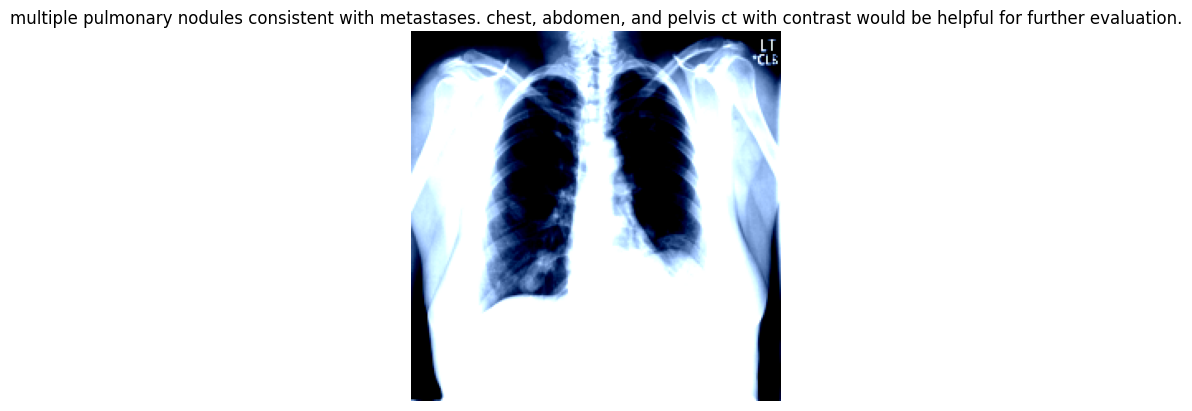

In [17]:
def tokens_to_string(tokens, inv_vocab):
    # Convert tensor to list, find words, and filter out <PAD>
    words = [inv_vocab.get(t.item(), "<UNK>") for t in tokens if t.item() != 0]
    return " ".join(words)

# Grab one sample from the training set
sample_img, sample_finding_tensor = train_set[0]
# Display sample_img using matplotlib to confirm it matches the description

actual_text = tokens_to_string(sample_finding_tensor, inv_vocab)

import matplotlib.pyplot as plt
# Convert the tensor back to a NumPy array for plotting
sample_img_np = sample_img.permute(1, 2, 0).numpy()
plt.imshow(sample_img_np)
plt.title(actual_text)
plt.axis('off')
plt.show()